# Support Ticket Classification System

## Future Interns - Machine Learning Task 2

This project uses Natural Language Processing (NLP) and Machine Learning to automatically classify customer support tickets into categories such as Hardware, Access, Storage, HR Support, etc.

### Technologies Used
- Python
- Pandas
- NLTK
- Scikit-learn
- TF-IDF Vectorization
- Logistic Regression

### Features
- Text Cleaning
- Feature Extraction
- Ticket Classification
- Accuracy Evaluation
- Confusion Matrix
- Real-time Predictions

In [1]:
import pandas as pd

df = pd.read_csv("../datasets/all_tickets_processed_improved_v3.csv")

df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [2]:
print(df.shape)

print(df.columns)

df.info()

(47837, 2)
Index(['Document', 'Topic_group'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Document     47837 non-null  str  
 1   Topic_group  47837 non-null  str  
dtypes: str(2)
memory usage: 747.6 KB


In [5]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['Cleaned_Document'] = df['Document'].apply(clean_text)

df[['Document', 'Cleaned_Document']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Document,Cleaned_Document
0,connection with icon icon dear please setup ic...,connection icon icon dear please setup icon pe...
1,work experience user work experience user hi w...,work experience user work experience user hi w...
2,requesting for meeting requesting meeting hi p...,requesting meeting requesting meeting hi pleas...
3,reset passwords for external accounts re expir...,reset passwords external accounts expire days ...
4,mail verification warning hi has got attached ...,mail verification warning hi got attached plea...


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['Cleaned_Document'])

y = df['Topic_group']

print(X.shape)
print(y.shape)

(47837, 5000)
(47837,)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = MultinomialNB()

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7613921404682275


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create model
lr_model = LogisticRegression(max_iter=1000)

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8510660535117057


In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

                       precision    recall  f1-score   support

               Access       0.92      0.87      0.89      1455
Administrative rights       0.86      0.67      0.76       342
           HR Support       0.85      0.84      0.84      2107
             Hardware       0.80      0.89      0.84      2760
     Internal Project       0.93      0.80      0.86       451
        Miscellaneous       0.81      0.83      0.82      1400
             Purchase       0.97      0.87      0.92       497
              Storage       0.93      0.84      0.89       556

             accuracy                           0.85      9568
            macro avg       0.88      0.83      0.85      9568
         weighted avg       0.86      0.85      0.85      9568



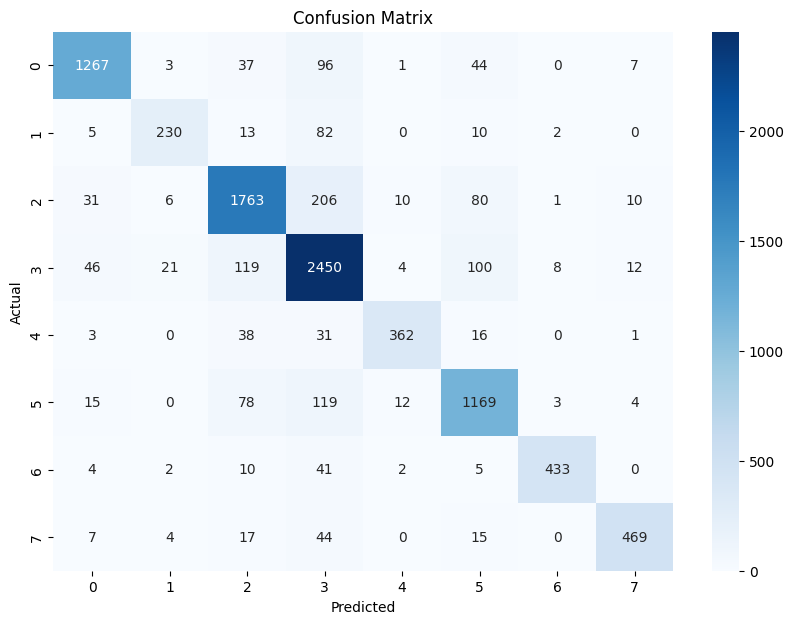

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(10,7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [12]:
sample_tickets = [
    "Unable to login to my account",
    "Need access to company storage",
    "Laptop screen is not working",
    "Requesting software installation",
    "Password reset issue"
]

sample_cleaned = [clean_text(ticket) for ticket in sample_tickets]

sample_vectorized = tfidf.transform(sample_cleaned)

predictions = lr_model.predict(sample_vectorized)

for ticket, pred in zip(sample_tickets, predictions):
    print(f"Ticket: {ticket}")
    print(f"Predicted Category: {pred}")
    print("-" * 50)

Ticket: Unable to login to my account
Predicted Category: Access
--------------------------------------------------
Ticket: Need access to company storage
Predicted Category: Storage
--------------------------------------------------
Ticket: Laptop screen is not working
Predicted Category: Hardware
--------------------------------------------------
Ticket: Requesting software installation
Predicted Category: Administrative rights
--------------------------------------------------
Ticket: Password reset issue
Predicted Category: Access
--------------------------------------------------


In [13]:
new_tickets = [
    "Internet is very slow in office",
    "My webcam is not detecting",
    "Need salary slip for last month",
    "Unable to connect to VPN",
    "Printer is not printing documents",
    "Need permission to install Zoom",
    "System getting restarted automatically",
    "Want leave approval for tomorrow"
]

new_cleaned = [clean_text(ticket) for ticket in new_tickets]

new_vectorized = tfidf.transform(new_cleaned)

new_predictions = lr_model.predict(new_vectorized)

for ticket, pred in zip(new_tickets, new_predictions):
    print(f"Ticket: {ticket}")
    print(f"Predicted Category: {pred}")
    print("-" * 50)

Ticket: Internet is very slow in office
Predicted Category: Hardware
--------------------------------------------------
Ticket: My webcam is not detecting
Predicted Category: Hardware
--------------------------------------------------
Ticket: Need salary slip for last month
Predicted Category: Hardware
--------------------------------------------------
Ticket: Unable to connect to VPN
Predicted Category: Hardware
--------------------------------------------------
Ticket: Printer is not printing documents
Predicted Category: Hardware
--------------------------------------------------
Ticket: Need permission to install Zoom
Predicted Category: Hardware
--------------------------------------------------
Ticket: System getting restarted automatically
Predicted Category: Hardware
--------------------------------------------------
Ticket: Want leave approval for tomorrow
Predicted Category: Miscellaneous
--------------------------------------------------
